ИМПОРТ НЕОБХОДИМЫХ БИБЛИОТЕК

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from catboost import CatBoostRegressor
from scipy.stats import alpha
from sklearn.model_selection import train_test_split
PROJECT_ROOT = Path('/Users/apch/Pycharmproekti/nn_real_estate')

ПРОВЕРКА ДАННЫХ

In [2]:
df = pd.read_csv('/Users/apch/Pycharmproekti/nn_real_estate/data/processed/dataset_with_geo.csv')
df = df.dropna(how='all')
df['district'] = df['district'].fillna('unknown')
df['material'] = df['material'].fillna('unknown')
print(f"Количество строк: {len(df)}, количество признаков: {len(df.columns)}")
print(f"Признаки: {df.columns}")
df.head()

Количество строк: 4322, количество признаков: 27
Признаки: Index(['rooms', 'district', 'year', 'material', 'price', 'total_area',
       'living_area', 'kitchen_area', 'current_floor', 'max_floor', 'is_ready',
       'metro', 'mini_disctrict', 'price_mln', 'price_log', 'is_last_floor',
       'is_first_floor', 'living_ratio', 'kitchen_ratio', 'floor_ratio',
       'area_floor_interaction', 'district_ready', 'material_age',
       'area_ratio_to_district', 'floor_category', 'distance_to_center',
       'distance_to_metro'],
      dtype='str')


,rooms,district,year,material,price,total_area,living_area,kitchen_area,current_floor,max_floor,...,living_ratio,kitchen_ratio,floor_ratio,area_floor_interaction,district_ready,material_age,area_ratio_to_district,floor_category,distance_to_center,distance_to_metro
0,1.0,Сормовский район,0.0,монолитный железобетон,8699992.0,38.76,12.08,16.62,4.0,16.0,...,0.311662,0.428793,0.250000,155.04,Сормовский район_1.0,монолитный железобетон_False,0.773471,low,8.078509,3.793034
1,2.0,Приокский район,49.0,кирпич,6500000.0,45.50,28.00,7.00,2.0,9.0,...,0.615385,0.153846,0.222222,91.00,Приокский район_1.0,кирпич_False,0.852629,low,11.317008,4.783442
2,2.0,Советский район,0.0,кирпич,20130935.0,53.50,24.00,12.00,7.0,9.0,...,0.448598,0.224299,0.777778,374.50,Советский район_1.0,кирпич_False,0.927442,high,NaN,NaN
3,2.0,Советский район,NaN,unknown,8350000.0,59.60,NaN,NaN,18.0,19.0,...,NaN,NaN,0.947368,1072.80,NaN,unknown_False,1.033188,high,NaN,NaN
4,2.0,Советский район,4.0,блок+утеплитель,16850000.0,63.00,28.00,22.00,11.0,15.0,...,0.444444,0.349206,0.733333,693.00,Советский район_1.0,блок+утеплитель_False,1.092128,high,4.928207,3.290123


РАСПРЕДЕЛЕНИЕ ВОЗРАСТА ЗДАНИЙ ПО РАЙОНАМ

<Axes: xlabel='district', ylabel='year'>

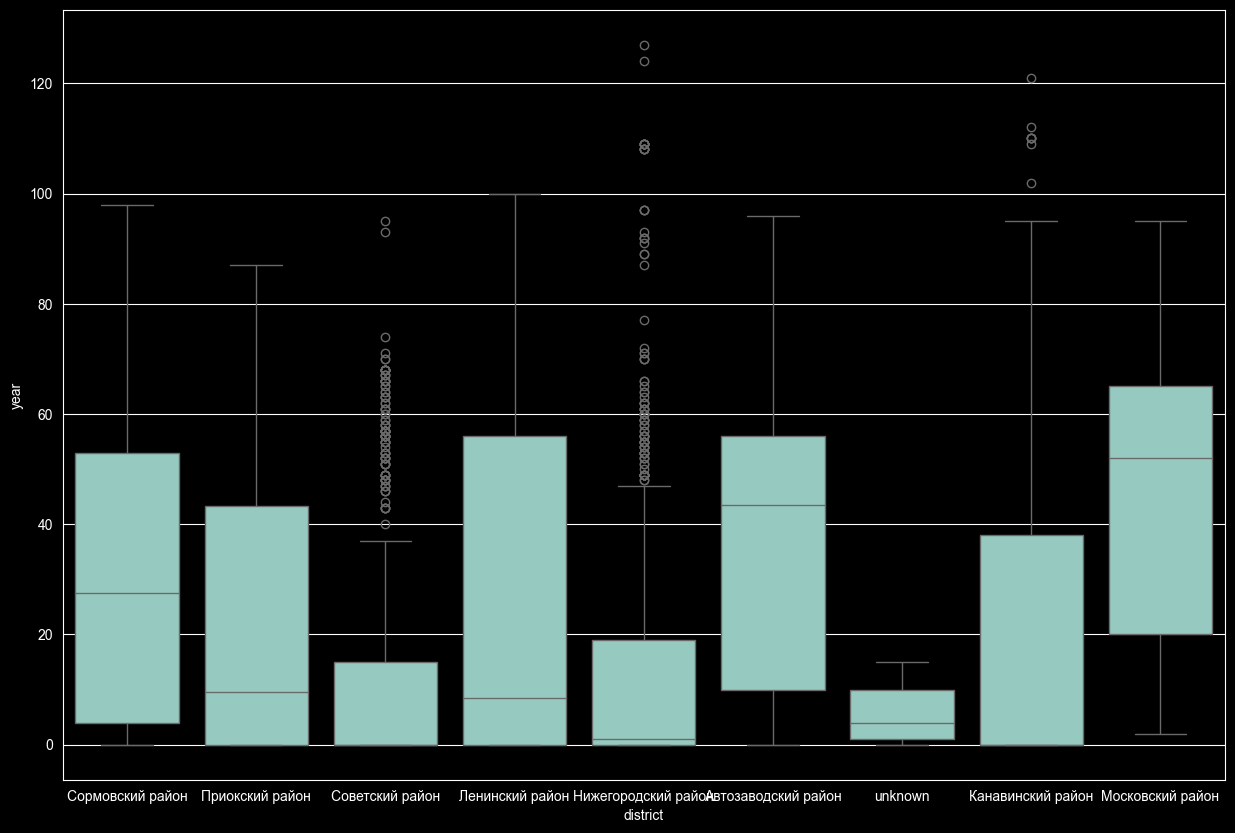

In [3]:
df['price_mln'] = df['price'] / 1_000_000
plt.figure(figsize=(15, 10))
sns.boxplot(x='district', y='year', data=df)

ЛОГАРИФМИРОВАНИЕ ЦЕНЫ

In [4]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = (Q3 - Q1)
upper_bound = Q3 + 1.5 * IQR
print(len(df[df['price'] >= upper_bound]))
print((294 / len(df) * 100))
df['price_log'] = np.log(df['price'])
print(df['price'].median())
print(df['price'].mean())
df.columns


294
6.802406293382693
9675350.0
12371941.32184174


Index(['rooms', 'district', 'year', 'material', 'price', 'total_area',
       'living_area', 'kitchen_area', 'current_floor', 'max_floor', 'is_ready',
       'metro', 'mini_disctrict', 'price_mln', 'price_log', 'is_last_floor',
       'is_first_floor', 'living_ratio', 'kitchen_ratio', 'floor_ratio',
       'area_floor_interaction', 'district_ready', 'material_age',
       'area_ratio_to_district', 'floor_category', 'distance_to_center',
       'distance_to_metro'],
      dtype='str')

ПРОВЕРКА МОДЕЛИ

In [5]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, accuracy_score, precision_score
from sklearn.model_selection import KFold
# РАБОТА С ПРИЗНАКАМИ
lower = df['price'].quantile(0.01)
upper = df['price'].quantile(0.99)
df_test = df[~df['district'].isin(['Московский район', 'unknown'])] #  с  удалением редких районов
df_clean = df[(df['price'] >= lower) & (df['price'] <= upper)] # с удалением выбросов
features = ['rooms', 'district', 'year', 'material',  'total_area',
       'living_area', 'kitchen_area', 'mini_disctrict', 'current_floor', 'max_floor', 'is_ready',
       'metro', 'is_last_floor',
       'is_first_floor', 'living_ratio', 'kitchen_ratio', 'floor_ratio',
       'area_floor_interaction', 'district_ready',
       'area_ratio_to_district', 'floor_category', 'distance_to_center',
       'distance_to_metro']
df['is_center'] = (df['distance_to_center'] < 1.5).astype(int)
df['is_near_metro'] = (df['distance_to_metro'] < 1).astype(int)
#features_to_remove = ['is_last_floor', 'is_first_floor', 'floor_category']
features_1 = [
    # Числовые
    'rooms',
    'total_area',
    'year',
    'living_area',
    'kitchen_area',
    'current_floor',
    'max_floor',
    'is_center',
    'is_near_metro',
    'kitchen_ratio',
    'area_floor_interaction',
    'area_ratio_to_district',
    'distance_to_center',
    'distance_to_metro',
    # Категориальные (попадают в cat_features)
    'district',
    'material',
    'mini_disctrict',
    'district_ready',
    'material_age',
    'metro'
]
for col in ['material', 'mini_disctrict', 'district_ready']:
    print(f"\n{col}:")
    print(df[col].value_counts())



material:
material
кирпич                                   1462
unknown                                  1103
блок+утеплитель                           827
панель                                    598
монолитный железобетон                    268
шлакоблок                                  37
дерево                                     17
поризованный керамический блок              5
стеновая панель на деревянном каркасе       5
Name: count, dtype: int64

mini_disctrict:
mini_disctrict
мкр. Центр              168
м. Горьковская          105
мкр. Мещерское озеро     48
мкр. Соцгород            37
мкр. Молитовка           35
                       ... 
6                         1
мкр. Светлоярский         1
мкр. Стройплощадка        1
12                        1
мкр. Карповка             1
Name: count, Length: 87, dtype: int64

district_ready:
district_ready
Нижегородский район_1.0    872
Советский район_1.0        686
Канавинский район_1.0      486
Автозаводский район_1.0    418
Ленинс

In [6]:
# РАБОТА С ТЕСТОВОЙ ВЫБОРКОЙ
X = df[features_1]
y = df['price']
y_log = df['price_log']
cat_features_1 = [
    'district',
    'material',
    'mini_disctrict',
    'district_ready',
    'material_age',
    'metro'
]
for col in cat_features_1:
    X[col] = X[col].astype(str).fillna('unknown')
    X[col] = X[col].replace('nan', 'unknown')
    print(f"{col}: NaN осталось = {X[col].isna().sum()}")
# Split=
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
print(X_train['district'].value_counts())
print(X_test['district'].value_counts())
print(df['mini_disctrict'].value_counts())



district: NaN осталось = 0
material: NaN осталось = 0
mini_disctrict: NaN осталось = 0
district_ready: NaN осталось = 0
material_age: NaN осталось = 0
metro: NaN осталось = 0
district
Нижегородский район    908
Советский район        640
Канавинский район      477
Автозаводский район    414
Сормовский район       271
Ленинский район        256
Приокский район        249
Московский район       178
unknown                 64
Name: count, dtype: int64
district
Нижегородский район    216
Советский район        163
Канавинский район      139
Автозаводский район    115
Сормовский район        63
Ленинский район         58
Приокский район         50
Московский район        41
unknown                 20
Name: count, dtype: int64
mini_disctrict
мкр. Центр              168
м. Горьковская          105
мкр. Мещерское озеро     48
мкр. Соцгород            37
мкр. Молитовка           35
                       ... 
6                         1
мкр. Светлоярский         1
мкр. Стройплощадка        1
12

R²: 0.8796
MAE: 1,704,709 ₽
MAPE: 12.29%


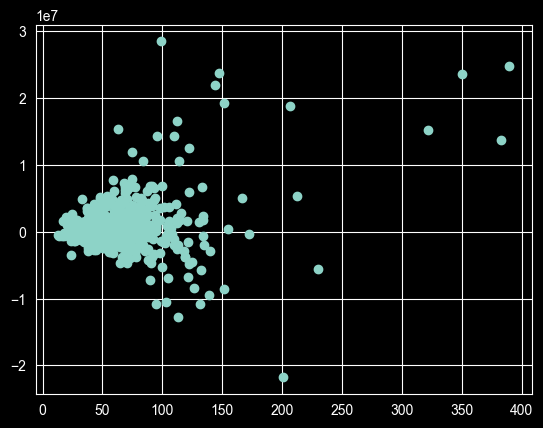

In [7]:
# РАБОТА С МОДЕЛЬЮ
from sklearn.metrics import r2_score
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

model = CatBoostRegressor(
    cat_features=cat_features_1,
    depth=5,
    iterations=600,
    learning_rate=0.06,
    l2_leaf_reg=5,
    random_seed=42,
    loss_function='Quantile',
    verbose=False,
)
weights = np.where(y_train_log > 20_000_000, 2.0, 1.0)
weights = np.where(y_train_log < 7_000_000, 1.2, weights)

model.fit(X_train,
          y_train_log,
          sample_weight=weights)
         # Оценка
pred_test = np.exp(model.predict(X_test))
# Реальные цены
y_test_true = np.exp(y_test_log)

# Метрики
r2 = r2_score(y_test_true, pred_test)
mae = mean_absolute_error(y_test_true, pred_test)
mape = mean_absolute_percentage_error(y_test_true, pred_test) * 100

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:,.0f} ₽")
print(f"MAPE: {mape:.2f}%")
residuals = y_test_true - pred_test

# Посмотрите на остатки по признакам
plt.scatter(X_test['total_area'], residuals)


In [18]:
        #ПРОВЕРКА MAPE & MAE
# Добавь в анализ
test_results = pd.DataFrame({
    'actual': y_test_true,
    'pred': pred_test,
    'error_rub': y_test_true - pred_test,
    'error_pct': (y_test_true - pred_test) / (y_test_true) * 100
})

# Ошибки на дорогих (> 20 млн)
expensive = test_results[test_results['actual'] > 20_000_000]
print("Дорогие квартиры (>20 млн):")
print(f"  MAPE: {expensive['error_pct'].abs().mean():.2f}%")
print(f"  MAE: {expensive['error_rub'].abs().mean():,.0f} ₽")
print(f"Дорогих квартир: {len(df[df['price'] > 20000000])}")

# Ошибки на дешёвых (< 7 млн)
cheap = test_results[ test_results['actual'] < 7_000_000]
print("Дешёвые квартиры (<7 млн):")
print(f"  MAPE: {cheap['error_pct'].abs().mean():.2f}%")
print(f"  MAE: {cheap['error_rub'].abs().mean():,.0f} ₽")
print(f"Дешевых квартир: {len(df[df['price'] < 7000000])}")
# Ошибки на средних (< 7 млн)
avg = test_results[(test_results['actual'] > 7_000_000) & (test_results['actual'] < 20_000_000)]
print("Средние квартиры (>7 млн & 20млн рубл<):")
print(f"  MAPE: {avg['error_pct'].abs().mean():.2f}%")
print(f"  MAE: {avg['error_rub'].abs().mean():,.0f} ₽")
print(f"Квартир среднего ценового сегмента: {len(df[(df['price'] < 20_000_000) & (df['price'] > 7_000_000)])}")
#test: 865
errors = np.abs(y_test_true-pred_test)
bootstrap_n = 10000
mae_bootstrap = [
    np.mean(np.random.choice(errors, len(errors), replace=True))
    for _ in range(bootstrap_n)
]
ci_low = np.percentile(mae_bootstrap, 2.5)
ci_high = np.percentile(mae_bootstrap, 97.5)
print(f"MAE: {np.mean(errors) / 1e6:.2f}")
print(f"95% CI: [{ci_low/1e6:.2f}, {ci_high/1e6:.2f}] млн рублей")

Дорогие квартиры (>20 млн):
  MAPE: 16.14%
  MAE: 5,565,918 ₽
Дорогих квартир: 542
Дешёвые квартиры (<7 млн):
  MAPE: 13.07%
  MAE: 599,415 ₽
Дешевых квартир: 1199
Средние квартиры (>7 млн & 20млн рубл<):
  MAPE: 11.02%
  MAE: 1,341,987 ₽
Квартир среднего ценового сегмента: 2556
MAE: 1.70
95% CI: [1.51, 1.90] млн рублей


In [16]:
# После обучения модели
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Обратное преобразование (если использовал логарифм)
y_train_pred_price = np.exp(y_train_pred)
y_test_pred_price = np.exp(y_test_pred)

y_train_true = np.exp(y_train_log)
y_test_true = np.exp(y_test_log)

# R² на трейне и тесте
r2_train = r2_score(y_train_true, y_train_pred_price)
r2_test = r2_score(y_test_true, y_test_pred_price)

print(f"R² train: {r2_train:.4f}")
print(f"R² test:  {r2_test:.4f}")
print(f"Разница: {r2_train - r2_test:.4f}")

R² train: 0.8654
R² test:  0.8796
Разница: -0.0142


In [12]:
    # ПРОВЕРКА МОДЕЛИ И МЕТРИК
from sklearn.model_selection import StratifiedKFold
y_binned = pd.qcut(y, q=10, labels=False)
strata = X['district'].astype(str) + "_" + y_binned.astype(str)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=41)
r2_scores = []
spisok = [42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32]
for sc in spisok:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=sc)
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, strata)):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y_log.iloc[train_idx], y_log.iloc[val_idx]

        model_cv = CatBoostRegressor(
            cat_features=cat_features_1,
            one_hot_max_size=None,
            depth=5,
            l2_leaf_reg=5,
            learning_rate=0.06,
            iterations=600,
            random_seed=42,
            verbose=False
        )

        model_cv.fit(X_train_cv, y_train_cv, verbose=False)
        y_pred = np.exp(model_cv.predict(X_val_cv))
        y_true = np.exp(y_val_cv)
        r2_cv = r2_score(y_true, y_pred)
        r2_scores.append(r2_cv)
       # print(f"Fold {fold+1}: {r2_cv:.4f}")
    print(f"\nR² = {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
   # print(f"Фолды: {[round(x, 3) for x in r2_scores]}")


R² = 0.841 ± 0.031

R² = 0.841 ± 0.038

R² = 0.843 ± 0.037

R² = 0.844 ± 0.035

R² = 0.844 ± 0.038

R² = 0.845 ± 0.041

R² = 0.845 ± 0.040

R² = 0.844 ± 0.040

R² = 0.844 ± 0.040

R² = 0.844 ± 0.039

R² = 0.844 ± 0.039


In [13]:
# Выбираем только числовые признаки
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Добавляем цену
df_corr = pd.concat([X[numeric_cols], y], axis=1)

# Корреляция с ценой (только цена)
corr_with_price = df_corr.corr()['price'].drop('price').sort_values(ascending=False)

print("=== Корреляция признаков с ценой ===\n")
for feature, corr in corr_with_price.items():
    print(f"{feature}: {corr:.3f}")

=== Корреляция признаков с ценой ===

total_area: 0.783
area_ratio_to_district: 0.623
kitchen_area: 0.620
living_area: 0.612
area_floor_interaction: 0.467
rooms: 0.457
is_center: 0.194
current_floor: 0.132
max_floor: 0.128
kitchen_ratio: 0.082
is_near_metro: 0.051
distance_to_metro: -0.271
year: -0.312
distance_to_center: -0.407


In [213]:
# from catboost import CatBoostClassifier
# from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score, accuracy_score, precision_score
# y_clf = (df['price'] > 20_000_000).astype(int)
# train_idx = X_train.index
# test_idx = X_test.index
# X_train_clf = X_train
# X_test_clf = X_test
# y_train_clf = y_clf.loc[train_idx]
# y_test_clf = y_clf.loc[test_idx]
# clf = CatBoostClassifier(
#     cat_features=cat_features_1,
#     depth = 4,
#     iterations = 300,
#     learning_rate = 0.05,
#     class_weights= {0: 1.0, 1: 2.5},
#     random_seed=42,
#     verbose=50
# )
# clf.fit(X_train_clf, y_train_clf)
# # Оценка
# y_pred_clf = clf.predict(X_test_clf)
# y_pred_proba = clf.predict_proba(X_test_clf)[:, 1]
# print(f"Классификатор")
# print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.3f}")
# print(f"Precision: {precision_score(y_test_clf, y_pred_clf):.3f}")
# print(f"Recall: {recall_score(y_test_clf, y_pred_clf):.3f}")
# print(f"F1: {f1_score(y_test_clf, y_pred_clf):.3f}")
# print(f"ROC-AUC: {roc_auc_score(y_test_clf, y_pred_proba):.3f}")

0:	learn: 0.6455753	total: 3.05ms	remaining: 913ms
50:	learn: 0.1732962	total: 89.5ms	remaining: 437ms
100:	learn: 0.1433324	total: 167ms	remaining: 328ms
150:	learn: 0.1266235	total: 250ms	remaining: 247ms
200:	learn: 0.1132577	total: 332ms	remaining: 164ms
250:	learn: 0.0997659	total: 413ms	remaining: 80.6ms
299:	learn: 0.0887498	total: 497ms	remaining: 0us
Классификатор
Accuracy: 0.965
Precision: 0.837
Recall: 0.923
F1: 0.878
ROC-AUC: 0.991


In [219]:
# # РАБОТА С МОДЕЛЬЮ
# from sklearn.metrics import r2_score
# from catboost import CatBoostClassifier
# import warnings
# warnings.filterwarnings('ignore')
# THRESHOLD = 20_000_000
# y_clf = (df['price'] >20_000_000).astype(int)
# mask_regular = df['price'] < THRESHOLD
# mask_expensive = df['price'] > THRESHOLD
# train_idx = X_train.index
# mask_regular_train = (df.loc[train_idx, 'price'] <= THRESHOLD)
# mask_expensive_train = (df.loc[train_idx, 'price'] > THRESHOLD)
# model_regular = CatBoostRegressor(
#     cat_features=cat_features_1,
#     depth=5,
#     iterations=600,
#     learning_rate=0.06,
#     l2_leaf_reg=5,
#     random_seed=42,
#     verbose=False
#     )
# model_regular.fit(X_train[mask_regular_train],
#                   y_train_log[mask_regular_train])
#          # Оценка
# model_expensive = CatBoostRegressor(
#     cat_features=cat_features_1,
#     depth=3,
#     iterations=150,
#     learning_rate=0.06,
#     l2_leaf_reg=10,
#     random_seed=42,
#     verbose=False
# )
# model_expensive.fit(X_train[mask_expensive_train],
#                     y_train_log[mask_expensive_train])
# clf = CatBoostClassifier(
#     cat_features=cat_features_1,
#     depth=4,
#     iterations=300,
#     learning_rate=0.05,
#     class_weights={0: 1.0, 1: 5.0},
#     random_seed=42,
#     verbose=False
# )
# clf.fit(X_train, y_train_clf)
# print(f"Обычных в train: {mask_regular_train.sum()}")
# print(f"Дорогих в train: {mask_expensive_train.sum()}")
# print(f"Классификатор обучен на {len(X_train)} объектах")
# # Предсказание на тесте
# is_expensive_test = clf.predict(X_test)
#
# # Каскад
# pred_test = np.zeros(len(X_test))
# pred_test[is_expensive_test == 0] = np.exp(model_regular.predict(X_test[is_expensive_test == 0]))
# pred_test[is_expensive_test == 1] = np.exp(model_expensive.predict(X_test[is_expensive_test == 1]))
#
# # Реальные цены
# y_test_true = np.exp(y_test_log)
#
# # Метрики
# r2 = r2_score(y_test_true, pred_test)
# mae = mean_absolute_error(y_test_true, pred_test)
# mape = mean_absolute_percentage_error(y_test_true, pred_test) * 100
#
# print("=== КАСКАДНАЯ МОДЕЛЬ ===")
# print(f"R²: {r2:.4f}")
# print(f"MAE: {mae:,.0f} ₽")
# print(f"MAPE: {mape:.2f}%")
#
# # Сравнение с обычной моделью
# print("\n=== СРАВНЕНИЕ ===")
# print(f"Обычная модель R²: 0.871")
# print(f"Каскадная модель R²: {r2:.4f}")
# print(f"Улучшение: {(r2 - 0.871):.4f}")

Обычных в train: 3032
Дорогих в train: 425
Классификатор обучен на 3457 объектах
=== КАСКАДНАЯ МОДЕЛЬ ===
R²: 0.8262
MAE: 1,979,659 ₽
MAPE: 14.15%

=== СРАВНЕНИЕ ===
Обычная модель R²: 0.871
Каскадная модель R²: 0.8262
Улучшение: -0.0448
